# S15_Interpretability_Unified_Framework

## Introduction

This notebook constructs a unified interpretability framework for the post-myocardial infarction classification study by integrating complementary sources of evidence:

1. permutation-based attribution magnitude,
2. ablation-based functional impact,
3. cross-variant stability,
4. winner-model diagnostic context.

The goal is not to treat feature importance as a single quantity, but to evaluate whether attribution strength, functional contribution, and stability converge on the same set of features. The notebook produces a unified feature table, computes stability and reliability metrics, derives a Feature Reliability Score (FRS), and generates publication-ready outputs for the third manuscript.

## Imports & config & Paths

In [16]:

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

INPUT_DIR = Path(".")
OUT_DIR = INPUT_DIR / "S15_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "variants": ["FULL", "CLINICAL", "BIOMARKERS"],
    "top_k": 5,
    "high_threshold": 0.67,
    "eps": 1e-12,
    "clip_negative_importance": True,
    "clip_negative_ablation": True,
}

VARIANTS = CONFIG["variants"]
TOP_K = CONFIG["top_k"]
EPS = CONFIG["eps"]

with open(OUT_DIR / "S15_config_snapshot.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

## File map

This section defines the file structure used in the notebook. The workflow expects the exported outputs from S6, S7, and S10 for each feature-space variant.

In [17]:
FILE_MAP = {
    variant: {
        "importance": INPUT_DIR / f"S6_{variant}_perm_importance_outer.csv",
        "ablation": INPUT_DIR / f"S7_{variant}_ablation_rerunS2.csv",
        "diag_summary": INPUT_DIR / f"S10_{variant}__SUMMARY.csv",
        "diag_true": INPUT_DIR / f"S10_{variant}__TRUE.csv",
        "diag_perm": INPUT_DIR / f"S10_{variant}__PERM.csv",
        "features_final": INPUT_DIR / f"S10_{variant}__features_used_final.csv",
    }
    for variant in VARIANTS
}

for variant, mapping in FILE_MAP.items():
    print(f"\n{variant}")
    for key, path in mapping.items():
        print(f"{key:>14}: {path.name} | exists={path.exists()}")


FULL
    importance: S6_FULL_perm_importance_outer.csv | exists=True
      ablation: S7_FULL_ablation_rerunS2.csv | exists=True
  diag_summary: S10_FULL__SUMMARY.csv | exists=True
     diag_true: S10_FULL__TRUE.csv | exists=True
     diag_perm: S10_FULL__PERM.csv | exists=True
features_final: S10_FULL__features_used_final.csv | exists=True

CLINICAL
    importance: S6_CLINICAL_perm_importance_outer.csv | exists=True
      ablation: S7_CLINICAL_ablation_rerunS2.csv | exists=True
  diag_summary: S10_CLINICAL__SUMMARY.csv | exists=True
     diag_true: S10_CLINICAL__TRUE.csv | exists=True
     diag_perm: S10_CLINICAL__PERM.csv | exists=True
features_final: S10_CLINICAL__features_used_final.csv | exists=True

BIOMARKERS
    importance: S6_BIOMARKERS_perm_importance_outer.csv | exists=True
      ablation: S7_BIOMARKERS_ablation_rerunS2.csv | exists=True
  diag_summary: S10_BIOMARKERS__SUMMARY.csv | exists=True
     diag_true: S10_BIOMARKERS__TRUE.csv | exists=True
     diag_perm: S10_BIOMAR

## Helper functions

The following functions standardize loading, normalization, and scoring across variants.

In [18]:
def minmax01(series, constant_value=0.0):
    s = pd.Series(series, dtype=float)
    if s.notna().sum() == 0:
        return pd.Series(np.nan, index=s.index)
    s_min = s.min(skipna=True)
    s_max = s.max(skipna=True)
    if pd.isna(s_min) or pd.isna(s_max) or np.isclose(s_max - s_min, 0.0):
        return pd.Series(constant_value, index=s.index, dtype=float)
    return (s - s_min) / (s_max - s_min)


def safe_numeric(series):
    return pd.to_numeric(series, errors="coerce")


def top_k_flag(values, k=5, ascending=False):
    s = pd.Series(values, dtype=float)
    valid = s.dropna()
    if valid.empty:
        return pd.Series(0, index=s.index, dtype=int)
    ranked = valid.rank(method="min", ascending=ascending)
    out = pd.Series(0, index=s.index, dtype=int)
    out.loc[ranked.index] = (ranked <= k).astype(int)
    return out


def load_csv(path):
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def normalize_rank_from_importance(df, feature_col="feature", value_col="perm_auc_drop"):
    work = df[[feature_col, value_col]].copy()
    work[value_col] = safe_numeric(work[value_col])
    work = work.dropna(subset=[feature_col, value_col]).drop_duplicates(subset=[feature_col])
    work["rank_from_importance"] = work[value_col].rank(ascending=False, method="dense")
    return work


def compute_cross_variant_consistency(df, value_col="importance_mean_nonneg"):
    pivot = df.pivot(index="feature", columns="variant", values=value_col)

    presence = pivot.notna().sum(axis=1)

    z = pivot.apply(
        lambda col: (col - col.mean()) / (col.std(ddof=0) + EPS),
        axis=0
    )

    spread = z.max(axis=1, skipna=True) - z.min(axis=1, skipna=True)

    consistency = 1 - minmax01(
        spread.fillna(spread.max(skipna=True) if spread.notna().any() else 0),
        constant_value=0.0
    )

    consistency.loc[presence <= 1] = np.nan

    out = consistency.rename("cross_variant_consistency").reset_index()
    return out


def model_significance_score(summary_df):
    work = summary_df.copy()

    work["auc_sig"] = 1 - safe_numeric(work["auc_mean_p_value"])
    work["mcc_sig"] = 1 - safe_numeric(work["mcc_mean_p_value"])

    work["auc_effect"] = (
        (safe_numeric(work["auc_mean_true"]) - safe_numeric(work["auc_mean_perm_mean"])) /
        (safe_numeric(work["auc_mean_perm_sd"]) + EPS)
    )

    work["mcc_effect"] = (
        (safe_numeric(work["mcc_mean_true"]) - safe_numeric(work["mcc_mean_perm_mean"])) /
        (safe_numeric(work["mcc_mean_perm_sd"]) + EPS)
    )

    work["diag_signal_raw"] = work[["auc_sig", "mcc_sig"]].mean(axis=1)
    work["diag_effect_raw"] = work[["auc_effect", "mcc_effect"]].mean(axis=1)

    work["diag_signal_score"] = minmax01(work["diag_signal_raw"], constant_value=0.0)
    work["diag_effect_score"] = minmax01(work["diag_effect_raw"], constant_value=0.0)

    work["model_reliability_score"] = work[["diag_signal_score", "diag_effect_score"]].mean(axis=1)

    keep = [
        "variant", "model",
        "auc_mean_true", "auc_mean_perm_mean", "auc_mean_perm_sd", "auc_mean_p_value",
        "mcc_mean_true", "mcc_mean_perm_mean", "mcc_mean_perm_sd", "mcc_mean_p_value",
        "diag_signal_score", "diag_effect_score", "model_reliability_score"
    ]
    return work[keep].sort_values(["variant", "model"]).reset_index(drop=True)


def shorten_label(text, max_len=24):
    text = str(text)
    return text if len(text) <= max_len else text[:max_len - 3] + "..."


def annotate_top_points(ax, data, x_col, y_col, label_col, n=5, fontsize=8):
    sub = data.dropna(subset=[x_col, y_col]).copy()
    if sub.empty:
        return

    x_span = max(sub[x_col].max() - sub[x_col].min(), EPS)
    y_span = max(sub[y_col].max() - sub[y_col].min(), EPS)

    offsets = [
        (0.010 * x_span, 0.020 * y_span),
        (0.010 * x_span, -0.035 * y_span),
        (-0.020 * x_span, 0.020 * y_span),
        (-0.020 * x_span, -0.035 * y_span),
        (0.018 * x_span, 0.040 * y_span),
    ]

    for i, (_, row) in enumerate(sub.head(n).iterrows()):
        dx, dy = offsets[i % len(offsets)]
        ax.annotate(
            shorten_label(row[label_col]),
            xy=(row[x_col], row[y_col]),
            xytext=(row[x_col] + dx, row[y_col] + dy),
            textcoords="data",
            fontsize=fontsize,
            ha="left",
            va="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.75),
            arrowprops=dict(arrowstyle="-", lw=0.6, alpha=0.5)
        )

## Winner models and diagnostic context

This section loads the model-level diagnostic summaries and identifies the winner model per variant from the permutation-diagnostic benchmark.

In [19]:
winner_by_variant = load_csv(INPUT_DIR / "S8_revised_winner_by_variant.csv")
winner_by_variant = winner_by_variant[
    ["variant", "model", "auc_mean", "auc_sd", "mcc_mean", "mcc_sd", "n_features"]
].copy()

diag_summary_all = []

for variant in VARIANTS:
    diag_summary_path = FILE_MAP[variant]["diag_summary"]
    tmp = load_csv(diag_summary_path).copy()
    diag_summary_all.append(tmp)

diag_summary_all = pd.concat(diag_summary_all, ignore_index=True)

diag_model_scores = model_significance_score(diag_summary_all)

winner_diagnostics = winner_by_variant.merge(
    diag_model_scores,
    on=["variant", "model"],
    how="left",
    validate="one_to_one"
).sort_values("variant").reset_index(drop=True)

winner_diagnostics.to_csv(OUT_DIR / "S15_winner_model_diagnostics.csv", index=False)
winner_diagnostics

,variant,model,auc_mean,auc_sd,mcc_mean,mcc_sd,n_features,auc_mean_true,auc_mean_perm_mean,auc_mean_perm_sd,auc_mean_p_value,mcc_mean_true,mcc_mean_perm_mean,mcc_mean_perm_sd,mcc_mean_p_value,diag_signal_score,diag_effect_score,model_reliability_score
0,BIOMARKERS,RF_SHALLOW,0.916190,0.076384,0.739048,0.151388,10,0.90,0.524054,0.112790,0.019608,0.568114,0.018203,0.170747,0.019608,1.00000,0.549557,0.774779
1,CLINICAL,RF_SHALLOW,0.612381,0.147450,0.198326,0.317574,42,0.55,0.477382,0.127142,0.294118,0.052632,-0.010816,0.148711,0.294118,0.45098,0.113102,0.282041
2,FULL,LR_L1,1.000000,0.000000,0.969031,0.069249,53,1.00,0.503049,0.096563,0.019608,0.960000,0.019933,0.162617,0.019608,1.00000,0.893124,0.946562


In [20]:
records = []

for variant in VARIANTS:
    importance_path = FILE_MAP[variant]["importance"]
    ablation_path = FILE_MAP[variant]["ablation"]

    importance_raw = load_csv(importance_path).copy()
    ablation_raw = load_csv(ablation_path).copy()

    # -------------------------
    # Importance table
    # -------------------------
    importance_df = normalize_rank_from_importance(
        importance_raw,
        feature_col="feature",
        value_col="perm_auc_drop"
    ).rename(columns={
        "perm_auc_drop": "importance_mean_raw",
        "rank_from_importance": "importance_rank"
    })

    importance_df["importance_mean_raw"] = safe_numeric(importance_df["importance_mean_raw"])
    importance_df["importance_mean_nonneg"] = importance_df["importance_mean_raw"].clip(lower=0)
    importance_df["variant"] = variant

    # -------------------------
    # Ablation table
    # -------------------------
    if "removed_feature" not in ablation_raw.columns:
        raise KeyError(f"[{variant}] Missing 'removed_feature' column in ablation file.")

    ablation_raw["auc_mean"] = safe_numeric(ablation_raw["auc_mean"])
    ablation_raw["auc_oof"] = safe_numeric(ablation_raw["auc_oof"])

    baseline_row = ablation_raw.loc[
        ablation_raw["removed_feature"].astype(str).str.upper() == "NONE"
    ].copy()

    if baseline_row.empty:
        raise ValueError(f"[{variant}] No baseline row with removed_feature == 'NONE' found.")

    if len(baseline_row) > 1:
        raise ValueError(f"[{variant}] Multiple baseline rows with removed_feature == 'NONE' found.")

    baseline_auc_mean = baseline_row["auc_mean"].iloc[0]
    baseline_auc_oof = baseline_row["auc_oof"].iloc[0]

    ablation_df = ablation_raw.loc[
        ablation_raw["removed_feature"].astype(str).str.upper() != "NONE"
    ].copy()

    ablation_df["ablation_delta_auc_mean_raw"] = baseline_auc_mean - ablation_df["auc_mean"]
    ablation_df["ablation_delta_auc_oof_raw"] = baseline_auc_oof - ablation_df["auc_oof"]

    ablation_df["ablation_delta_auc_mean"] = ablation_df["ablation_delta_auc_mean_raw"].clip(lower=0)
    ablation_df["ablation_delta_auc_oof"] = ablation_df["ablation_delta_auc_oof_raw"].clip(lower=0)

    ablation_df["variant"] = variant
    ablation_df = ablation_df.rename(columns={"removed_feature": "feature"})

    ablation_df = ablation_df[[
        "variant",
        "feature",
        "k_removed",
        "auc_mean",
        "auc_sd",
        "mcc_mean",
        "mcc_sd",
        "auc_oof",
        "ablation_delta_auc_mean_raw",
        "ablation_delta_auc_oof_raw",
        "ablation_delta_auc_mean",
        "ablation_delta_auc_oof",
    ]].copy()

    merged = importance_df.merge(
        ablation_df,
        on=["variant", "feature"],
        how="left",
        validate="one_to_one"
    )

    n_importance = importance_df["feature"].nunique()
    n_ablation = ablation_df["feature"].nunique()
    n_merged = merged["feature"].nunique()

    print(
        f"[{variant}] importance={n_importance} | "
        f"ablation={n_ablation} | merged={n_merged} | "
        f"missing_ablation={merged['ablation_delta_auc_mean'].isna().sum()}"
    )

    records.append(merged)

feature_unified = pd.concat(records, ignore_index=True)

feature_unified = feature_unified.sort_values(
    ["variant", "importance_rank", "feature"]
).reset_index(drop=True)

feature_unified.head(20)

[FULL] importance=54 | ablation=20 | merged=54 | missing_ablation=34
[CLINICAL] importance=43 | ablation=20 | merged=43 | missing_ablation=23
[BIOMARKERS] importance=10 | ablation=9 | merged=10 | missing_ablation=1


,feature,importance_mean_raw,importance_rank,importance_mean_nonneg,variant,k_removed,auc_mean,auc_sd,mcc_mean,mcc_sd,auc_oof,ablation_delta_auc_mean_raw,ablation_delta_auc_oof_raw,ablation_delta_auc_mean,ablation_delta_auc_oof
0,72_kda_pro_mmp_2,0.285683,1.0,0.285683,BIOMARKERS,1.0,0.810476,0.140553,0.551658,0.188535,0.765625,0.137619,0.148750,0.137619,0.148750
1,emmprin,0.058841,2.0,0.058841,BIOMARKERS,2.0,0.702857,0.103884,0.255212,0.271576,0.666875,0.245238,0.247500,0.245238,0.247500
2,wyniki_fgf23_pg_ml,0.048952,3.0,0.048952,BIOMARKERS,3.0,0.607619,0.151096,0.112360,0.132934,0.616250,0.340476,0.298125,0.340476,0.298125
3,tnfalfa_pg_ml,0.029333,4.0,0.029333,BIOMARKERS,4.0,0.544286,0.164403,-0.083304,0.254292,0.559375,0.403810,0.355000,0.403810,0.355000
4,hdl,0.021032,5.0,0.021032,BIOMARKERS,5.0,0.473333,0.178575,-0.045393,0.310982,0.536250,0.474762,0.378125,0.474762,0.378125
5,ldl,0.001444,6.0,0.001444,BIOMARKERS,6.0,0.483333,0.177233,0.038020,0.314464,0.507500,0.464762,0.406875,0.464762,0.406875
6,il_6_pg_ml,0.000825,7.0,0.000825,BIOMARKERS,7.0,0.519048,0.134265,0.042727,0.304181,0.485000,0.429048,0.429375,0.429048,0.429375
7,non_hdl_calkowity_hdl,-0.002476,8.0,0.000000,BIOMARKERS,8.0,0.366190,0.082657,-0.168031,0.212546,0.378750,0.581905,0.535625,0.581905,0.535625
8,wyniki_klotho_pg_ml,-0.005190,9.0,0.000000,BIOMARKERS,9.0,0.391429,0.132326,0.021473,0.268555,0.417500,0.556667,0.496875,0.556667,0.496875
9,cholesterol_calkowity_tc,-0.005921,10.0,0.000000,BIOMARKERS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Attach winner-model context

In [21]:
feature_unified = feature_unified.merge(
    winner_diagnostics[
        ["variant", "model", "model_reliability_score", "diag_signal_score", "diag_effect_score"]
    ].rename(columns={
        "model": "winner_model",
        "model_reliability_score": "winner_model_reliability_score",
        "diag_signal_score": "winner_diag_signal_score",
        "diag_effect_score": "winner_diag_effect_score",
    }),
    on="variant",
    how="left",
    validate="many_to_one"
)

feature_unified.head(20)

,feature,importance_mean_raw,importance_rank,importance_mean_nonneg,variant,k_removed,auc_mean,auc_sd,mcc_mean,mcc_sd,auc_oof,ablation_delta_auc_mean_raw,ablation_delta_auc_oof_raw,ablation_delta_auc_mean,ablation_delta_auc_oof,winner_model,winner_model_reliability_score,winner_diag_signal_score,winner_diag_effect_score
0,72_kda_pro_mmp_2,0.285683,1.0,0.285683,BIOMARKERS,1.0,0.810476,0.140553,0.551658,0.188535,0.765625,0.137619,0.148750,0.137619,0.148750,RF_SHALLOW,0.774779,1.00000,0.549557
1,emmprin,0.058841,2.0,0.058841,BIOMARKERS,2.0,0.702857,0.103884,0.255212,0.271576,0.666875,0.245238,0.247500,0.245238,0.247500,RF_SHALLOW,0.774779,1.00000,0.549557
2,wyniki_fgf23_pg_ml,0.048952,3.0,0.048952,BIOMARKERS,3.0,0.607619,0.151096,0.112360,0.132934,0.616250,0.340476,0.298125,0.340476,0.298125,RF_SHALLOW,0.774779,1.00000,0.549557
3,tnfalfa_pg_ml,0.029333,4.0,0.029333,BIOMARKERS,4.0,0.544286,0.164403,-0.083304,0.254292,0.559375,0.403810,0.355000,0.403810,0.355000,RF_SHALLOW,0.774779,1.00000,0.549557
4,hdl,0.021032,5.0,0.021032,BIOMARKERS,5.0,0.473333,0.178575,-0.045393,0.310982,0.536250,0.474762,0.378125,0.474762,0.378125,RF_SHALLOW,0.774779,1.00000,0.549557
5,ldl,0.001444,6.0,0.001444,BIOMARKERS,6.0,0.483333,0.177233,0.038020,0.314464,0.507500,0.464762,0.406875,0.464762,0.406875,RF_SHALLOW,0.774779,1.00000,0.549557
6,il_6_pg_ml,0.000825,7.0,0.000825,BIOMARKERS,7.0,0.519048,0.134265,0.042727,0.304181,0.485000,0.429048,0.429375,0.429048,0.429375,RF_SHALLOW,0.774779,1.00000,0.549557
7,non_hdl_calkowity_hdl,-0.002476,8.0,0.000000,BIOMARKERS,8.0,0.366190,0.082657,-0.168031,0.212546,0.378750,0.581905,0.535625,0.581905,0.535625,RF_SHALLOW,0.774779,1.00000,0.549557
8,wyniki_klotho_pg_ml,-0.005190,9.0,0.000000,BIOMARKERS,9.0,0.391429,0.132326,0.021473,0.268555,0.417500,0.556667,0.496875,0.556667,0.496875,RF_SHALLOW,0.774779,1.00000,0.549557
9,cholesterol_calkowity_tc,-0.005921,10.0,0.000000,BIOMARKERS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RF_SHALLOW,0.774779,1.00000,0.549557


## Construct feature-level metrics

In [22]:
feature_unified["importance_mean_raw"] = safe_numeric(feature_unified["importance_mean_raw"])
feature_unified["importance_mean_nonneg"] = safe_numeric(feature_unified["importance_mean_nonneg"])
feature_unified["importance_rank"] = safe_numeric(feature_unified["importance_rank"])

feature_unified["ablation_delta_auc_mean_raw"] = safe_numeric(feature_unified["ablation_delta_auc_mean_raw"])
feature_unified["ablation_delta_auc_oof_raw"] = safe_numeric(feature_unified["ablation_delta_auc_oof_raw"])
feature_unified["ablation_delta_auc_mean"] = safe_numeric(feature_unified["ablation_delta_auc_mean"])
feature_unified["ablation_delta_auc_oof"] = safe_numeric(feature_unified["ablation_delta_auc_oof"])

feature_unified["topk_importance_flag"] = (
    feature_unified.groupby("variant")["importance_mean_nonneg"]
    .transform(lambda s: top_k_flag(s, k=TOP_K, ascending=False))
)

feature_unified["topk_ablation_flag"] = (
    feature_unified.groupby("variant")["ablation_delta_auc_mean"]
    .transform(lambda s: top_k_flag(s, k=TOP_K, ascending=False))
)

feature_unified["topk_joint_flag"] = (
    (feature_unified["topk_importance_flag"] == 1) &
    (feature_unified["topk_ablation_flag"] == 1)
).astype(int)

feature_unified["importance_score"] = (
    feature_unified.groupby("variant")["importance_mean_nonneg"]
    .transform(lambda s: minmax01(s, constant_value=0.0))
)

feature_unified["rank_score"] = 1 - (
    feature_unified.groupby("variant")["importance_rank"]
    .transform(lambda s: minmax01(s, constant_value=0.0))
)

feature_unified["ablation_score"] = (
    feature_unified.groupby("variant")["ablation_delta_auc_mean"]
    .transform(lambda s: minmax01(s, constant_value=0.0))
)

feature_unified["joint_topk_score"] = feature_unified["topk_joint_flag"].astype(float)

cross_variant = compute_cross_variant_consistency(
    feature_unified,
    value_col="importance_mean_nonneg"
)

feature_unified = feature_unified.merge(
    cross_variant,
    on="feature",
    how="left",
    validate="many_to_one"
)

feature_unified["stability_score"] = feature_unified[
    ["rank_score", "cross_variant_consistency"]
].mean(axis=1, skipna=True)

feature_unified["functional_consistency_score"] = feature_unified[
    ["ablation_score", "joint_topk_score"]
].mean(axis=1, skipna=True)

feature_unified["FRS_raw"] = (
    feature_unified["stability_score"] +
    feature_unified["functional_consistency_score"] +
    feature_unified["importance_score"]
) / 3

feature_unified["FRS"] = (
    feature_unified.groupby("variant")["FRS_raw"]
    .transform(lambda s: minmax01(s, constant_value=0.0))
)

feature_unified["FRS_rank"] = (
    feature_unified.groupby("variant")["FRS"]
    .rank(ascending=False, method="dense")
)

feature_unified["interpretability_gap"] = (
    feature_unified["importance_score"] - feature_unified["functional_consistency_score"]
)

feature_unified.head(20)

,feature,importance_mean_raw,importance_rank,importance_mean_nonneg,variant,k_removed,auc_mean,auc_sd,mcc_mean,mcc_sd,auc_oof,ablation_delta_auc_mean_raw,ablation_delta_auc_oof_raw,ablation_delta_auc_mean,ablation_delta_auc_oof,winner_model,winner_model_reliability_score,winner_diag_signal_score,winner_diag_effect_score,topk_importance_flag,topk_ablation_flag,topk_joint_flag,importance_score,rank_score,ablation_score,joint_topk_score,cross_variant_consistency,stability_score,functional_consistency_score,FRS_raw,FRS,FRS_rank,interpretability_gap
0,72_kda_pro_mmp_2,0.285683,1.0,0.285683,BIOMARKERS,1.0,0.810476,0.140553,0.551658,0.188535,0.765625,0.137619,0.148750,0.137619,0.148750,RF_SHALLOW,0.774779,1.00000,0.549557,1,0,0,1.000000,1.000000,0.000000,0.0,0.607730,0.803865,0.000000,0.601288,1.000000,1.0,1.000000
1,emmprin,0.058841,2.0,0.058841,BIOMARKERS,2.0,0.702857,0.103884,0.255212,0.271576,0.666875,0.245238,0.247500,0.245238,0.247500,RF_SHALLOW,0.774779,1.00000,0.549557,1,0,0,0.205967,0.888889,0.242229,0.0,0.958375,0.923632,0.121115,0.416905,0.587990,4.0,0.084853
2,wyniki_fgf23_pg_ml,0.048952,3.0,0.048952,BIOMARKERS,3.0,0.607619,0.151096,0.112360,0.132934,0.616250,0.340476,0.298125,0.340476,0.298125,RF_SHALLOW,0.774779,1.00000,0.549557,1,0,0,0.171352,0.777778,0.456592,0.0,0.959027,0.868402,0.228296,0.422684,0.600903,3.0,-0.056943
3,tnfalfa_pg_ml,0.029333,4.0,0.029333,BIOMARKERS,4.0,0.544286,0.164403,-0.083304,0.254292,0.559375,0.403810,0.355000,0.403810,0.355000,RF_SHALLOW,0.774779,1.00000,0.549557,1,0,0,0.102678,0.666667,0.599143,0.0,0.965755,0.816211,0.299571,0.406153,0.563966,5.0,-0.196893
4,hdl,0.021032,5.0,0.021032,BIOMARKERS,5.0,0.473333,0.178575,-0.045393,0.310982,0.536250,0.474762,0.378125,0.474762,0.378125,RF_SHALLOW,0.774779,1.00000,0.549557,1,1,1,0.073619,0.555556,0.758842,1.0,0.975067,0.765311,0.879421,0.572784,0.936306,2.0,-0.805802
5,ldl,0.001444,6.0,0.001444,BIOMARKERS,6.0,0.483333,0.177233,0.038020,0.314464,0.507500,0.464762,0.406875,0.464762,0.406875,RF_SHALLOW,0.774779,1.00000,0.549557,0,1,0,0.005056,0.444444,0.736334,0.0,0.926200,0.685322,0.368167,0.352848,0.444855,7.0,-0.363111
6,il_6_pg_ml,0.000825,7.0,0.000825,BIOMARKERS,7.0,0.519048,0.134265,0.042727,0.304181,0.485000,0.429048,0.429375,0.429048,0.429375,RF_SHALLOW,0.774779,1.00000,0.549557,0,1,0,0.002889,0.333333,0.655949,0.0,0.924655,0.628994,0.327974,0.319953,0.371348,9.0,-0.325085
7,non_hdl_calkowity_hdl,-0.002476,8.0,0.000000,BIOMARKERS,8.0,0.366190,0.082657,-0.168031,0.212546,0.378750,0.581905,0.535625,0.581905,0.535625,RF_SHALLOW,0.774779,1.00000,0.549557,0,1,0,0.000000,0.222222,1.000000,0.0,0.922596,0.572409,0.500000,0.357470,0.455181,6.0,-0.500000
8,wyniki_klotho_pg_ml,-0.005190,9.0,0.000000,BIOMARKERS,9.0,0.391429,0.132326,0.021473,0.268555,0.417500,0.556667,0.496875,0.556667,0.496875,RF_SHALLOW,0.774779,1.00000,0.549557,0,1,0,0.000000,0.111111,0.943194,0.0,0.922596,0.516853,0.471597,0.329483,0.392645,8.0,-0.471597
9,cholesterol_calkowity_tc,-0.005921,10.0,0.000000,BIOMARKERS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RF_SHALLOW,0.774779,1.00000,0.549557,0,0,0,0.000000,0.000000,NaN,0.0,0.922596,0.461298,0.000000,0.153766,0.000000,10.0,0.000000


## Feature typology

In [23]:
HIGH_THR = CONFIG["high_threshold"]

def classify_feature(row):
    importance = row.get("importance_score", np.nan)
    ablation = row.get("ablation_score", np.nan)
    stability = row.get("stability_score", np.nan)

    if pd.isna(importance) or pd.isna(ablation) or pd.isna(stability):
        return "UNRESOLVED"

    high_importance = importance >= HIGH_THR
    high_ablation = ablation >= HIGH_THR
    high_stability = stability >= HIGH_THR

    if high_importance and high_ablation and high_stability:
        return "TRUE_SIGNAL"
    elif high_importance and not high_ablation:
        return "SPURIOUS_IMPORTANCE"
    elif (not high_importance) and high_ablation:
        return "HIDDEN_SIGNAL"
    else:
        return "LOW_SIGNAL"

feature_unified["feature_class"] = feature_unified.apply(classify_feature, axis=1)

feature_unified["feature_class"] = pd.Categorical(
    feature_unified["feature_class"],
    categories=[
        "TRUE_SIGNAL",
        "SPURIOUS_IMPORTANCE",
        "HIDDEN_SIGNAL",
        "LOW_SIGNAL",
        "UNRESOLVED",
    ],
    ordered=True
)

feature_unified.head(20)

,feature,importance_mean_raw,importance_rank,importance_mean_nonneg,variant,k_removed,auc_mean,auc_sd,mcc_mean,mcc_sd,auc_oof,ablation_delta_auc_mean_raw,ablation_delta_auc_oof_raw,ablation_delta_auc_mean,ablation_delta_auc_oof,winner_model,winner_model_reliability_score,winner_diag_signal_score,winner_diag_effect_score,topk_importance_flag,topk_ablation_flag,topk_joint_flag,importance_score,rank_score,ablation_score,joint_topk_score,cross_variant_consistency,stability_score,functional_consistency_score,FRS_raw,FRS,FRS_rank,interpretability_gap,feature_class
0,72_kda_pro_mmp_2,0.285683,1.0,0.285683,BIOMARKERS,1.0,0.810476,0.140553,0.551658,0.188535,0.765625,0.137619,0.148750,0.137619,0.148750,RF_SHALLOW,0.774779,1.00000,0.549557,1,0,0,1.000000,1.000000,0.000000,0.0,0.607730,0.803865,0.000000,0.601288,1.000000,1.0,1.000000,SPURIOUS_IMPORTANCE
1,emmprin,0.058841,2.0,0.058841,BIOMARKERS,2.0,0.702857,0.103884,0.255212,0.271576,0.666875,0.245238,0.247500,0.245238,0.247500,RF_SHALLOW,0.774779,1.00000,0.549557,1,0,0,0.205967,0.888889,0.242229,0.0,0.958375,0.923632,0.121115,0.416905,0.587990,4.0,0.084853,LOW_SIGNAL
2,wyniki_fgf23_pg_ml,0.048952,3.0,0.048952,BIOMARKERS,3.0,0.607619,0.151096,0.112360,0.132934,0.616250,0.340476,0.298125,0.340476,0.298125,RF_SHALLOW,0.774779,1.00000,0.549557,1,0,0,0.171352,0.777778,0.456592,0.0,0.959027,0.868402,0.228296,0.422684,0.600903,3.0,-0.056943,LOW_SIGNAL
3,tnfalfa_pg_ml,0.029333,4.0,0.029333,BIOMARKERS,4.0,0.544286,0.164403,-0.083304,0.254292,0.559375,0.403810,0.355000,0.403810,0.355000,RF_SHALLOW,0.774779,1.00000,0.549557,1,0,0,0.102678,0.666667,0.599143,0.0,0.965755,0.816211,0.299571,0.406153,0.563966,5.0,-0.196893,LOW_SIGNAL
4,hdl,0.021032,5.0,0.021032,BIOMARKERS,5.0,0.473333,0.178575,-0.045393,0.310982,0.536250,0.474762,0.378125,0.474762,0.378125,RF_SHALLOW,0.774779,1.00000,0.549557,1,1,1,0.073619,0.555556,0.758842,1.0,0.975067,0.765311,0.879421,0.572784,0.936306,2.0,-0.805802,HIDDEN_SIGNAL
5,ldl,0.001444,6.0,0.001444,BIOMARKERS,6.0,0.483333,0.177233,0.038020,0.314464,0.507500,0.464762,0.406875,0.464762,0.406875,RF_SHALLOW,0.774779,1.00000,0.549557,0,1,0,0.005056,0.444444,0.736334,0.0,0.926200,0.685322,0.368167,0.352848,0.444855,7.0,-0.363111,HIDDEN_SIGNAL
6,il_6_pg_ml,0.000825,7.0,0.000825,BIOMARKERS,7.0,0.519048,0.134265,0.042727,0.304181,0.485000,0.429048,0.429375,0.429048,0.429375,RF_SHALLOW,0.774779,1.00000,0.549557,0,1,0,0.002889,0.333333,0.655949,0.0,0.924655,0.628994,0.327974,0.319953,0.371348,9.0,-0.325085,LOW_SIGNAL
7,non_hdl_calkowity_hdl,-0.002476,8.0,0.000000,BIOMARKERS,8.0,0.366190,0.082657,-0.168031,0.212546,0.378750,0.581905,0.535625,0.581905,0.535625,RF_SHALLOW,0.774779,1.00000,0.549557,0,1,0,0.000000,0.222222,1.000000,0.0,0.922596,0.572409,0.500000,0.357470,0.455181,6.0,-0.500000,HIDDEN_SIGNAL
8,wyniki_klotho_pg_ml,-0.005190,9.0,0.000000,BIOMARKERS,9.0,0.391429,0.132326,0.021473,0.268555,0.417500,0.556667,0.496875,0.556667,0.496875,RF_SHALLOW,0.774779,1.00000,0.549557,0,1,0,0.000000,0.111111,0.943194,0.0,0.922596,0.516853,0.471597,0.329483,0.392645,8.0,-0.471597,HIDDEN_SIGNAL
9,cholesterol_calkowity_tc,-0.005921,10.0,0.000000,BIOMARKERS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RF_SHALLOW,0.774779,1.00000,0.549557,0,0,0,0.000000,0.000000,NaN,0.0,0.922596,0.461298,0.000000,0.153766,0.000000,10.0,0.000000,UNRESOLVED


## Variant-level correlation analysis

This section quantifies internal agreement among attribution magnitude, ranking, and functional impact within each variant.

In [24]:
corr_rows = []

for variant, sub in feature_unified.groupby("variant"):
    sub = sub.copy()

    corr_rows.append({
        "variant": variant,
        "n_features": int(sub["feature"].nunique()),
        "corr_importance_vs_ablation_spearman": sub["importance_mean_nonneg"].corr(
            sub["ablation_delta_auc_mean"], method="spearman"
        ),
        "corr_importance_vs_FRS_spearman": sub["importance_mean_nonneg"].corr(
            sub["FRS"], method="spearman"
        ),
        "corr_ablation_vs_FRS_spearman": sub["ablation_delta_auc_mean"].corr(
            sub["FRS"], method="spearman"
        ),
        "topk_overlap_importance_ablation": int(
            ((sub["topk_importance_flag"] == 1) & (sub["topk_ablation_flag"] == 1)).sum()
        ),
        "mean_absolute_gap": float(
            (sub["importance_score"] - sub["ablation_score"]).abs().mean()
        ),
        "median_absolute_gap": float(
            (sub["importance_score"] - sub["ablation_score"]).abs().median()
        ),
    })

corr_table = (
    pd.DataFrame(corr_rows)
    .sort_values("variant")
    .reset_index(drop=True)
)

corr_table.to_csv(OUT_DIR / "S15_variant_correlation_table.csv", index=False)
corr_table

,variant,n_features,corr_importance_vs_ablation_spearman,corr_importance_vs_FRS_spearman,corr_ablation_vs_FRS_spearman,topk_overlap_importance_ablation,mean_absolute_gap,median_absolute_gap
0,BIOMARKERS,10,-0.928878,0.816012,-0.533333,1,0.647858,0.685223
1,CLINICAL,43,-0.383385,0.453170,0.619990,0,0.384492,0.312500
2,FULL,54,-0.373526,0.530453,0.258647,1,0.712559,0.744949


## Unified feature table

The main output table is saved here. It is suitable for downstream figure generation and manuscript reporting.

In [25]:
feature_table = feature_unified[[
    "variant",
    "winner_model",
    "feature",

    "importance_mean_raw",
    "importance_mean_nonneg",
    "importance_rank",

    "ablation_delta_auc_mean_raw",
    "ablation_delta_auc_oof_raw",
    "ablation_delta_auc_mean",
    "ablation_delta_auc_oof",

    "importance_score",
    "rank_score",
    "ablation_score",
    "joint_topk_score",
    "cross_variant_consistency",
    "stability_score",
    "functional_consistency_score",

    "winner_diag_signal_score",
    "winner_diag_effect_score",
    "winner_model_reliability_score",

    "FRS_raw",
    "FRS",
    "FRS_rank",
    "interpretability_gap",

    "feature_class"
]].sort_values(
    ["variant", "FRS_rank", "importance_rank", "feature"]
).reset_index(drop=True)

feature_table.to_csv(OUT_DIR / "S15_feature_reliability_table.csv", index=False)
feature_table.head(30)

,variant,winner_model,feature,importance_mean_raw,importance_mean_nonneg,importance_rank,ablation_delta_auc_mean_raw,ablation_delta_auc_oof_raw,ablation_delta_auc_mean,ablation_delta_auc_oof,importance_score,rank_score,ablation_score,joint_topk_score,cross_variant_consistency,stability_score,functional_consistency_score,winner_diag_signal_score,winner_diag_effect_score,winner_model_reliability_score,FRS_raw,FRS,FRS_rank,interpretability_gap,feature_class
0,BIOMARKERS,RF_SHALLOW,72_kda_pro_mmp_2,0.285683,0.285683,1.0,0.137619,0.148750,0.137619,0.148750,1.000000,1.000000,0.000000,0.0,0.607730,0.803865,0.000000,1.00000,0.549557,0.774779,0.601288,1.000000,1.0,1.000000,SPURIOUS_IMPORTANCE
1,BIOMARKERS,RF_SHALLOW,hdl,0.021032,0.021032,5.0,0.474762,0.378125,0.474762,0.378125,0.073619,0.555556,0.758842,1.0,0.975067,0.765311,0.879421,1.00000,0.549557,0.774779,0.572784,0.936306,2.0,-0.805802,HIDDEN_SIGNAL
2,BIOMARKERS,RF_SHALLOW,wyniki_fgf23_pg_ml,0.048952,0.048952,3.0,0.340476,0.298125,0.340476,0.298125,0.171352,0.777778,0.456592,0.0,0.959027,0.868402,0.228296,1.00000,0.549557,0.774779,0.422684,0.600903,3.0,-0.056943,LOW_SIGNAL
3,BIOMARKERS,RF_SHALLOW,emmprin,0.058841,0.058841,2.0,0.245238,0.247500,0.245238,0.247500,0.205967,0.888889,0.242229,0.0,0.958375,0.923632,0.121115,1.00000,0.549557,0.774779,0.416905,0.587990,4.0,0.084853,LOW_SIGNAL
4,BIOMARKERS,RF_SHALLOW,tnfalfa_pg_ml,0.029333,0.029333,4.0,0.403810,0.355000,0.403810,0.355000,0.102678,0.666667,0.599143,0.0,0.965755,0.816211,0.299571,1.00000,0.549557,0.774779,0.406153,0.563966,5.0,-0.196893,LOW_SIGNAL
5,BIOMARKERS,RF_SHALLOW,non_hdl_calkowity_hdl,-0.002476,0.000000,8.0,0.581905,0.535625,0.581905,0.535625,0.000000,0.222222,1.000000,0.0,0.922596,0.572409,0.500000,1.00000,0.549557,0.774779,0.357470,0.455181,6.0,-0.500000,HIDDEN_SIGNAL
6,BIOMARKERS,RF_SHALLOW,ldl,0.001444,0.001444,6.0,0.464762,0.406875,0.464762,0.406875,0.005056,0.444444,0.736334,0.0,0.926200,0.685322,0.368167,1.00000,0.549557,0.774779,0.352848,0.444855,7.0,-0.363111,HIDDEN_SIGNAL
7,BIOMARKERS,RF_SHALLOW,wyniki_klotho_pg_ml,-0.005190,0.000000,9.0,0.556667,0.496875,0.556667,0.496875,0.000000,0.111111,0.943194,0.0,0.922596,0.516853,0.471597,1.00000,0.549557,0.774779,0.329483,0.392645,8.0,-0.471597,HIDDEN_SIGNAL
8,BIOMARKERS,RF_SHALLOW,il_6_pg_ml,0.000825,0.000825,7.0,0.429048,0.429375,0.429048,0.429375,0.002889,0.333333,0.655949,0.0,0.924655,0.628994,0.327974,1.00000,0.549557,0.774779,0.319953,0.371348,9.0,-0.325085,LOW_SIGNAL
9,BIOMARKERS,RF_SHALLOW,cholesterol_calkowity_tc,-0.005921,0.000000,10.0,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN,0.0,0.922596,0.461298,0.000000,1.00000,0.549557,0.774779,0.153766,0.000000,10.0,0.000000,UNRESOLVED


## Top features by variant

This section displays the highest-ranked features under the composite reliability framework for each variant.

In [26]:
top_tables = []

for variant in VARIANTS:
    sub = feature_table.query("variant == @variant").copy()
    n_total = sub["feature"].nunique()

    top_sub = (
        sub.query("feature_class != 'UNRESOLVED'")
        .sort_values(
            ["FRS_rank", "stability_score", "ablation_score"],
            ascending=[True, False, False]
        )
        .head(10)
        .copy()
    )

    top_sub["n_features_total"] = n_total
    top_tables.append(top_sub)

top_features_all = pd.concat(top_tables, ignore_index=True)

top_features_all.to_csv(OUT_DIR / "S15_top_features_by_variant.csv", index=False)
top_features_all

,variant,winner_model,feature,importance_mean_raw,importance_mean_nonneg,importance_rank,ablation_delta_auc_mean_raw,ablation_delta_auc_oof_raw,ablation_delta_auc_mean,ablation_delta_auc_oof,importance_score,rank_score,ablation_score,joint_topk_score,cross_variant_consistency,stability_score,functional_consistency_score,winner_diag_signal_score,winner_diag_effect_score,winner_model_reliability_score,FRS_raw,FRS,FRS_rank,interpretability_gap,feature_class,n_features_total
0,FULL,LR_L1,92_kda_pro_mmp_9,0.193111,0.193111,1.0,0.053333,0.083750,0.053333,0.083750,1.000000,1.000000,0.000000,0.0,NaN,1.000000,0.000000,1.00000,0.893124,0.946562,0.666667,1.000000,1.0,1.000000,SPURIOUS_IMPORTANCE,54
1,FULL,LR_L1,wyniki_fgf23_pg_ml,0.000476,0.000476,5.0,0.348571,0.369375,0.348571,0.369375,0.002466,0.428571,0.782828,1.0,0.959027,0.693799,0.891414,1.00000,0.893124,0.946562,0.529226,0.793840,2.0,-0.888948,HIDDEN_SIGNAL,54
2,FULL,LR_L1,emmprin,0.003524,0.003524,4.0,0.302857,0.343750,0.302857,0.343750,0.018248,0.571429,0.661616,0.0,0.958375,0.764902,0.330808,1.00000,0.893124,0.946562,0.371319,0.556979,3.0,-0.312561,LOW_SIGNAL,54
3,FULL,LR_L1,72_kda_pro_mmp_2,0.030841,0.030841,2.0,0.136190,0.196875,0.136190,0.196875,0.159707,0.857143,0.219697,0.0,0.607730,0.732436,0.109848,1.00000,0.893124,0.946562,0.333997,0.500996,4.0,0.049859,LOW_SIGNAL,54
4,FULL,LR_L1,bmi,0.000286,0.000286,6.0,0.330000,0.323125,0.330000,0.323125,0.001480,0.285714,0.733586,0.0,0.970219,0.627967,0.366793,1.00000,0.893124,0.946562,0.332080,0.498120,5.0,-0.365313,HIDDEN_SIGNAL,54
5,FULL,LR_L1,arb,0.000000,0.000000,8.0,0.430476,0.423125,0.430476,0.423125,0.000000,0.000000,1.000000,0.0,0.972471,0.486235,0.500000,1.00000,0.893124,0.946562,0.328745,0.493118,6.0,-0.500000,HIDDEN_SIGNAL,54
6,FULL,LR_L1,ile_lat_mizdzyca_konczyn,0.000000,0.000000,8.0,0.363333,0.376250,0.363333,0.376250,0.000000,0.000000,0.821970,0.0,0.972471,0.486235,0.410985,1.00000,0.893124,0.946562,0.299073,0.448610,7.0,-0.410985,HIDDEN_SIGNAL,54
7,FULL,LR_L1,crp_5_zapalenie,0.000000,0.000000,8.0,0.345238,0.366875,0.345238,0.366875,0.000000,0.000000,0.773990,0.0,0.972471,0.486235,0.386995,1.00000,0.893124,0.946562,0.291077,0.436615,8.0,-0.386995,HIDDEN_SIGNAL,54
8,FULL,LR_L1,ile_lat_miazdzyca_t_szyjnych,0.000000,0.000000,8.0,0.338571,0.355000,0.338571,0.355000,0.000000,0.000000,0.756313,0.0,0.972471,0.486235,0.378157,1.00000,0.893124,0.946562,0.288131,0.432196,9.0,-0.378157,HIDDEN_SIGNAL,54
9,FULL,LR_L1,petlowy,0.000000,0.000000,8.0,0.337143,0.338750,0.337143,0.338750,0.000000,0.000000,0.752525,0.0,0.972471,0.486235,0.376263,1.00000,0.893124,0.946562,0.287499,0.431249,10.0,-0.376263,HIDDEN_SIGNAL,54


## Plot 1. importance vs FRS

This plot shows whether strong attribution magnitude is aligned with the composite reliability score.

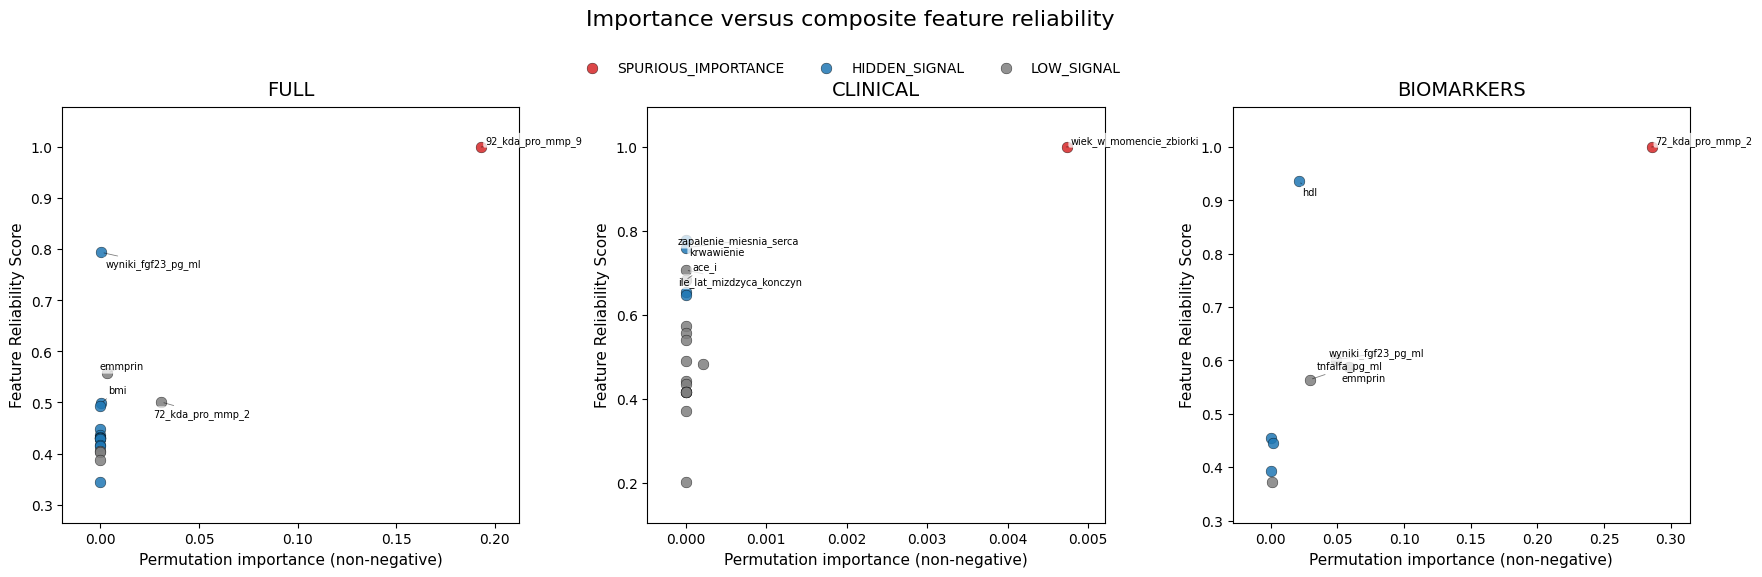

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))
fig.subplots_adjust(top=0.82, bottom=0.18, wspace=0.28)

class_colors = {
    "TRUE_SIGNAL": "#2ca02c",
    "SPURIOUS_IMPORTANCE": "#d62728",
    "HIDDEN_SIGNAL": "#1f77b4",
    "LOW_SIGNAL": "#7f7f7f",
    "UNRESOLVED": "#cccccc",
}

for ax, variant in zip(axes, VARIANTS):
    sub = feature_table.query("variant == @variant and feature_class != 'UNRESOLVED'").copy()

    for cls, color in class_colors.items():
        part = sub[sub["feature_class"] == cls]
        if part.empty:
            continue

        ax.scatter(
            part["importance_mean_nonneg"],
            part["FRS"],
            s=60,
            alpha=0.85,
            label=cls,
            color=color,
            edgecolor="black",
            linewidth=0.3
        )

    annotate_top_points(
        ax=ax,
        data=sub.sort_values("FRS", ascending=False),
        x_col="importance_mean_nonneg",
        y_col="FRS",
        label_col="feature",
        n=5,
        fontsize=7
    )

    ax.set_title(variant, fontsize=14, pad=8)
    ax.set_xlabel("Permutation importance (non-negative)", fontsize=11)
    ax.set_ylabel("Feature Reliability Score", fontsize=11)
    ax.tick_params(axis="both", labelsize=10)
    ax.margins(x=0.10, y=0.12)

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=5,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, 0.91)
)

fig.suptitle("Importance versus composite feature reliability", fontsize=16, y=0.97)

fig.savefig(
    OUT_DIR / "S15_plot_importance_vs_FRS.png",
    dpi=400,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)

## Plot 2. Importance versus ablation impact

This plot assesses whether features with high attribution magnitude also produce a substantial performance drop when removed.

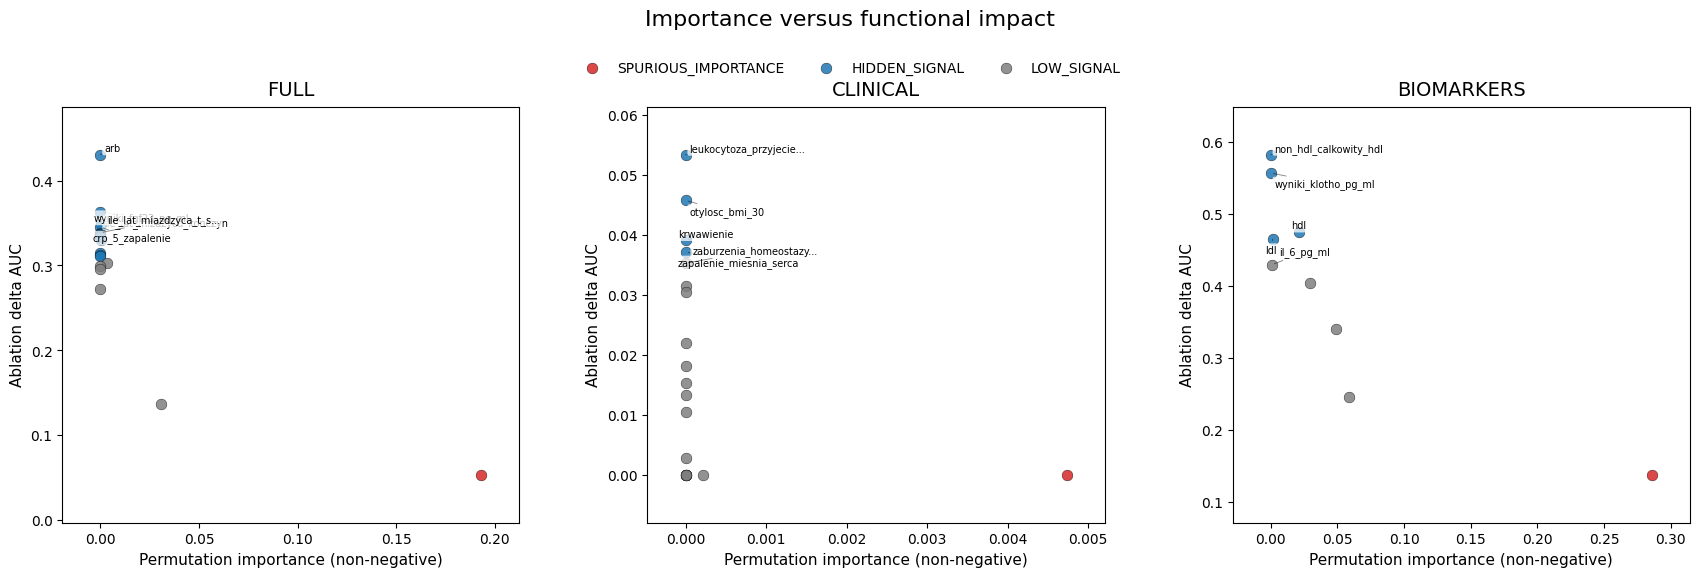

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6.5))
fig.subplots_adjust(top=0.82, bottom=0.18, wspace=0.28)

class_colors = {
    "TRUE_SIGNAL": "#2ca02c",
    "SPURIOUS_IMPORTANCE": "#d62728",
    "HIDDEN_SIGNAL": "#1f77b4",
    "LOW_SIGNAL": "#7f7f7f",
    "UNRESOLVED": "#cccccc",
}

for ax, variant in zip(axes, VARIANTS):
    sub = feature_table.query("variant == @variant and feature_class != 'UNRESOLVED'").copy()

    for cls, color in class_colors.items():
        part = sub[sub["feature_class"] == cls]
        if part.empty:
            continue

        ax.scatter(
            part["importance_mean_nonneg"],
            part["ablation_delta_auc_mean"],
            s=60,
            alpha=0.85,
            label=cls,
            color=color,
            edgecolor="black",
            linewidth=0.3
        )

    annotate_top_points(
        ax=ax,
        data=sub.sort_values("ablation_delta_auc_mean", ascending=False),
        x_col="importance_mean_nonneg",
        y_col="ablation_delta_auc_mean",
        label_col="feature",
        n=5,
        fontsize=7
    )

    ax.set_title(variant, fontsize=14, pad=8)
    ax.set_xlabel("Permutation importance (non-negative)", fontsize=11)
    ax.set_ylabel("Ablation delta AUC", fontsize=11)
    ax.tick_params(axis="both", labelsize=10)
    ax.margins(x=0.10, y=0.15)

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=5,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, 0.91)
)

fig.suptitle("Importance versus functional impact", fontsize=16, y=0.97)

fig.savefig(
    OUT_DIR / "S15_plot_importance_vs_ablation.png",
    dpi=400,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)

## Plot 3. Reliability map

This panel summarizes attribution magnitude, stability, and interpretability classes in a single two-dimensional view.

/tmp/ipykernel_15639/2851259251.py:38: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/tmp/ipykernel_15639/2851259251.py:38: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(
/tmp/ipykernel_15639/2851259251.py:38: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


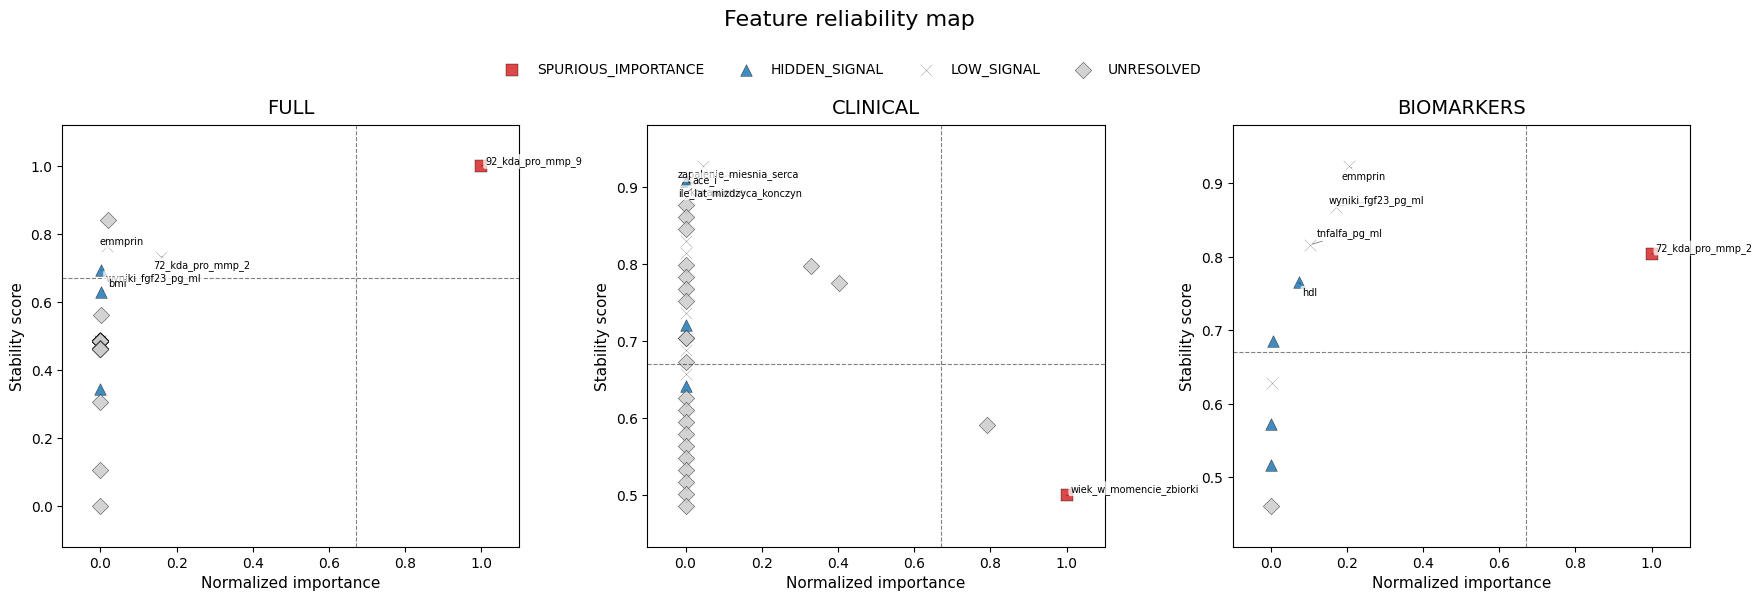

In [29]:
HIGH_THR = CONFIG["high_threshold"]

class_order = [
    "TRUE_SIGNAL",
    "SPURIOUS_IMPORTANCE",
    "HIDDEN_SIGNAL",
    "LOW_SIGNAL",
    "UNRESOLVED",
]

marker_map = {
    "TRUE_SIGNAL": "o",
    "SPURIOUS_IMPORTANCE": "s",
    "HIDDEN_SIGNAL": "^",
    "LOW_SIGNAL": "x",
    "UNRESOLVED": "D",
}

class_colors = {
    "TRUE_SIGNAL": "#2ca02c",
    "SPURIOUS_IMPORTANCE": "#d62728",
    "HIDDEN_SIGNAL": "#1f77b4",
    "LOW_SIGNAL": "#7f7f7f",
    "UNRESOLVED": "#cccccc",
}

fig, axes = plt.subplots(1, 3, figsize=(21, 6.8))
fig.subplots_adjust(top=0.80, bottom=0.18, wspace=0.28)

for ax, variant in zip(axes, VARIANTS):
    sub = feature_table.query("variant == @variant").copy()

    for cls in class_order:
        part = sub[sub["feature_class"] == cls]
        if part.empty:
            continue

        ax.scatter(
            part["importance_score"],
            part["stability_score"],
            s=70,
            marker=marker_map[cls],
            alpha=0.85,
            label=cls,
            color=class_colors[cls],
            edgecolor="black",
            linewidth=0.3
        )

    ax.axvline(HIGH_THR, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.axhline(HIGH_THR, color="black", linestyle="--", linewidth=0.8, alpha=0.5)

    annotate_top_points(
        ax=ax,
        data=sub.query("feature_class != 'UNRESOLVED'").sort_values("FRS", ascending=False),
        x_col="importance_score",
        y_col="stability_score",
        label_col="feature",
        n=5,
        fontsize=7
    )

    ax.set_title(variant, fontsize=14, pad=8)
    ax.set_xlabel("Normalized importance", fontsize=11)
    ax.set_ylabel("Stability score", fontsize=11)
    ax.tick_params(axis="both", labelsize=10)
    ax.margins(x=0.10, y=0.12)

handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=5,
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, 0.91)
)

fig.suptitle("Feature reliability map", fontsize=16, y=0.97)

fig.savefig(
    OUT_DIR / "S15_plot_reliability_map.png",
    dpi=400,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()
plt.close(fig)

## Summary tables

This section provides compact manuscript-ready summaries at the feature-class and variant levels.

In [30]:
class_summary = (
    feature_table.groupby(["variant", "feature_class"], observed=False)
    .agg(
        n_features=("feature", "nunique"),
        mean_importance_nonneg=("importance_mean_nonneg", "mean"),
        mean_ablation_delta_auc=("ablation_delta_auc_mean", "mean"),
        mean_stability=("stability_score", "mean"),
        mean_FRS=("FRS", "mean")
    )
    .reset_index()
    .sort_values(["variant", "feature_class"])
)

variant_summary = (
    feature_table.groupby("variant")
    .agg(
        n_features=("feature", "nunique"),
        n_unresolved=("feature_class", lambda s: int((s == "UNRESOLVED").sum())),
        mean_importance_nonneg=("importance_mean_nonneg", "mean"),
        mean_ablation_delta_auc=("ablation_delta_auc_mean", "mean"),
        mean_stability=("stability_score", "mean"),
        mean_winner_model_reliability=("winner_model_reliability_score", "mean"),
        mean_FRS=("FRS", "mean")
    )
    .reset_index()
    .sort_values("variant")
)

class_summary.to_csv(OUT_DIR / "S15_feature_class_summary.csv", index=False)
variant_summary.to_csv(OUT_DIR / "S15_variant_summary.csv", index=False)

class_summary, variant_summary

(       variant        feature_class  n_features  mean_importance_nonneg  mean_ablation_delta_auc  mean_stability  mean_FRS
 0   BIOMARKERS          TRUE_SIGNAL           0                     NaN                      NaN             NaN       NaN
 1   BIOMARKERS  SPURIOUS_IMPORTANCE           1                0.285683                 0.137619        0.803865  1.000000
 2   BIOMARKERS        HIDDEN_SIGNAL           4                0.005619                 0.519524        0.634974  0.557247
 3   BIOMARKERS           LOW_SIGNAL           4                0.034488                 0.354643        0.809310  0.531052
 4   BIOMARKERS           UNRESOLVED           1                0.000000                      NaN        0.461298  0.000000
 5     CLINICAL          TRUE_SIGNAL           0                     NaN                      NaN             NaN       NaN
 6     CLINICAL  SPURIOUS_IMPORTANCE           1                0.004730                 0.000000        0.500000  1.000000
 7     C

In [31]:
variant_summary

,variant,n_features,n_unresolved,mean_importance_nonneg,mean_ablation_delta_auc,mean_stability,mean_winner_model_reliability,mean_FRS
0,BIOMARKERS,10,1,0.044611,0.403810,0.704230,0.774779,0.535319
1,CLINICAL,43,23,0.000283,0.017714,0.743963,0.282041,0.389389
2,FULL,54,34,0.004301,0.306643,0.495687,0.946562,0.325798


## Export publication-ready subsets

This section saves concise files intended for direct use in the manuscript, supplementary tables, and figure assembly.

In [32]:
publication_subset = feature_table[[
    "variant",
    "feature",
    "winner_model",
    "importance_mean_nonneg",
    "importance_rank",
    "ablation_delta_auc_mean",
    "stability_score",
    "winner_model_reliability_score",
    "FRS",
    "FRS_rank",
    "feature_class"
]].sort_values(
    ["variant", "FRS_rank", "feature"]
)

publication_subset.to_csv(OUT_DIR / "S15_publication_subset.csv", index=False)
publication_subset.head(30)

,variant,feature,winner_model,importance_mean_nonneg,importance_rank,ablation_delta_auc_mean,stability_score,winner_model_reliability_score,FRS,FRS_rank,feature_class
0,BIOMARKERS,72_kda_pro_mmp_2,RF_SHALLOW,0.285683,1.0,0.137619,0.803865,0.774779,1.000000,1.0,SPURIOUS_IMPORTANCE
1,BIOMARKERS,hdl,RF_SHALLOW,0.021032,5.0,0.474762,0.765311,0.774779,0.936306,2.0,HIDDEN_SIGNAL
2,BIOMARKERS,wyniki_fgf23_pg_ml,RF_SHALLOW,0.048952,3.0,0.340476,0.868402,0.774779,0.600903,3.0,LOW_SIGNAL
3,BIOMARKERS,emmprin,RF_SHALLOW,0.058841,2.0,0.245238,0.923632,0.774779,0.587990,4.0,LOW_SIGNAL
4,BIOMARKERS,tnfalfa_pg_ml,RF_SHALLOW,0.029333,4.0,0.403810,0.816211,0.774779,0.563966,5.0,LOW_SIGNAL
5,BIOMARKERS,non_hdl_calkowity_hdl,RF_SHALLOW,0.000000,8.0,0.581905,0.572409,0.774779,0.455181,6.0,HIDDEN_SIGNAL
6,BIOMARKERS,ldl,RF_SHALLOW,0.001444,6.0,0.464762,0.685322,0.774779,0.444855,7.0,HIDDEN_SIGNAL
7,BIOMARKERS,wyniki_klotho_pg_ml,RF_SHALLOW,0.000000,9.0,0.556667,0.516853,0.774779,0.392645,8.0,HIDDEN_SIGNAL
8,BIOMARKERS,il_6_pg_ml,RF_SHALLOW,0.000825,7.0,0.429048,0.628994,0.774779,0.371348,9.0,LOW_SIGNAL
9,BIOMARKERS,cholesterol_calkowity_tc,RF_SHALLOW,0.000000,10.0,NaN,0.461298,0.774779,0.000000,10.0,UNRESOLVED


In [33]:
complete_case_subset = feature_table.dropna(
    subset=["importance_score", "ablation_score", "stability_score"]
).copy()

complete_case_subset.to_csv(OUT_DIR / "S15_complete_case_subset.csv", index=False)
complete_case_subset.head(20)

,variant,winner_model,feature,importance_mean_raw,importance_mean_nonneg,importance_rank,ablation_delta_auc_mean_raw,ablation_delta_auc_oof_raw,ablation_delta_auc_mean,ablation_delta_auc_oof,importance_score,rank_score,ablation_score,joint_topk_score,cross_variant_consistency,stability_score,functional_consistency_score,winner_diag_signal_score,winner_diag_effect_score,winner_model_reliability_score,FRS_raw,FRS,FRS_rank,interpretability_gap,feature_class
0,BIOMARKERS,RF_SHALLOW,72_kda_pro_mmp_2,0.285683,0.285683,1.0,0.137619,0.148750,0.137619,0.148750,1.000000,1.000000,0.000000,0.0,0.607730,0.803865,0.000000,1.00000,0.549557,0.774779,0.601288,1.000000,1.0,1.000000,SPURIOUS_IMPORTANCE
1,BIOMARKERS,RF_SHALLOW,hdl,0.021032,0.021032,5.0,0.474762,0.378125,0.474762,0.378125,0.073619,0.555556,0.758842,1.0,0.975067,0.765311,0.879421,1.00000,0.549557,0.774779,0.572784,0.936306,2.0,-0.805802,HIDDEN_SIGNAL
2,BIOMARKERS,RF_SHALLOW,wyniki_fgf23_pg_ml,0.048952,0.048952,3.0,0.340476,0.298125,0.340476,0.298125,0.171352,0.777778,0.456592,0.0,0.959027,0.868402,0.228296,1.00000,0.549557,0.774779,0.422684,0.600903,3.0,-0.056943,LOW_SIGNAL
3,BIOMARKERS,RF_SHALLOW,emmprin,0.058841,0.058841,2.0,0.245238,0.247500,0.245238,0.247500,0.205967,0.888889,0.242229,0.0,0.958375,0.923632,0.121115,1.00000,0.549557,0.774779,0.416905,0.587990,4.0,0.084853,LOW_SIGNAL
4,BIOMARKERS,RF_SHALLOW,tnfalfa_pg_ml,0.029333,0.029333,4.0,0.403810,0.355000,0.403810,0.355000,0.102678,0.666667,0.599143,0.0,0.965755,0.816211,0.299571,1.00000,0.549557,0.774779,0.406153,0.563966,5.0,-0.196893,LOW_SIGNAL
5,BIOMARKERS,RF_SHALLOW,non_hdl_calkowity_hdl,-0.002476,0.000000,8.0,0.581905,0.535625,0.581905,0.535625,0.000000,0.222222,1.000000,0.0,0.922596,0.572409,0.500000,1.00000,0.549557,0.774779,0.357470,0.455181,6.0,-0.500000,HIDDEN_SIGNAL
6,BIOMARKERS,RF_SHALLOW,ldl,0.001444,0.001444,6.0,0.464762,0.406875,0.464762,0.406875,0.005056,0.444444,0.736334,0.0,0.926200,0.685322,0.368167,1.00000,0.549557,0.774779,0.352848,0.444855,7.0,-0.363111,HIDDEN_SIGNAL
7,BIOMARKERS,RF_SHALLOW,wyniki_klotho_pg_ml,-0.005190,0.000000,9.0,0.556667,0.496875,0.556667,0.496875,0.000000,0.111111,0.943194,0.0,0.922596,0.516853,0.471597,1.00000,0.549557,0.774779,0.329483,0.392645,8.0,-0.471597,HIDDEN_SIGNAL
8,BIOMARKERS,RF_SHALLOW,il_6_pg_ml,0.000825,0.000825,7.0,0.429048,0.429375,0.429048,0.429375,0.002889,0.333333,0.655949,0.0,0.924655,0.628994,0.327974,1.00000,0.549557,0.774779,0.319953,0.371348,9.0,-0.325085,LOW_SIGNAL
10,CLINICAL,RF_SHALLOW,wiek_w_momencie_zbiorki,0.004730,0.004730,1.0,-0.015238,0.052500,0.000000,0.052500,1.000000,1.000000,0.000000,0.0,0.000000,0.500000,0.000000,0.45098,0.113102,0.282041,0.500000,1.000000,1.0,1.000000,SPURIOUS_IMPORTANCE


In [34]:
publication_subset_maintext = publication_subset.query(
    "feature_class != 'UNRESOLVED'"
).copy()

publication_subset_maintext.to_csv(
    OUT_DIR / "S15_publication_subset_maintext.csv",
    index=False
)

publication_subset_maintext.head(20)

,variant,feature,winner_model,importance_mean_nonneg,importance_rank,ablation_delta_auc_mean,stability_score,winner_model_reliability_score,FRS,FRS_rank,feature_class
0,BIOMARKERS,72_kda_pro_mmp_2,RF_SHALLOW,0.285683,1.0,0.137619,0.803865,0.774779,1.000000,1.0,SPURIOUS_IMPORTANCE
1,BIOMARKERS,hdl,RF_SHALLOW,0.021032,5.0,0.474762,0.765311,0.774779,0.936306,2.0,HIDDEN_SIGNAL
2,BIOMARKERS,wyniki_fgf23_pg_ml,RF_SHALLOW,0.048952,3.0,0.340476,0.868402,0.774779,0.600903,3.0,LOW_SIGNAL
3,BIOMARKERS,emmprin,RF_SHALLOW,0.058841,2.0,0.245238,0.923632,0.774779,0.587990,4.0,LOW_SIGNAL
4,BIOMARKERS,tnfalfa_pg_ml,RF_SHALLOW,0.029333,4.0,0.403810,0.816211,0.774779,0.563966,5.0,LOW_SIGNAL
5,BIOMARKERS,non_hdl_calkowity_hdl,RF_SHALLOW,0.000000,8.0,0.581905,0.572409,0.774779,0.455181,6.0,HIDDEN_SIGNAL
6,BIOMARKERS,ldl,RF_SHALLOW,0.001444,6.0,0.464762,0.685322,0.774779,0.444855,7.0,HIDDEN_SIGNAL
7,BIOMARKERS,wyniki_klotho_pg_ml,RF_SHALLOW,0.000000,9.0,0.556667,0.516853,0.774779,0.392645,8.0,HIDDEN_SIGNAL
8,BIOMARKERS,il_6_pg_ml,RF_SHALLOW,0.000825,7.0,0.429048,0.628994,0.774779,0.371348,9.0,LOW_SIGNAL
10,CLINICAL,wiek_w_momencie_zbiorki,RF_SHALLOW,0.004730,1.0,0.000000,0.500000,0.282041,1.000000,1.0,SPURIOUS_IMPORTANCE


In [35]:
coverage_summary = (
    feature_table.groupby("variant")
    .agg(
        n_features_total=("feature", "nunique"),
        n_complete=("feature_class", lambda s: int((s != "UNRESOLVED").sum())),
        n_unresolved=("feature_class", lambda s: int((s == "UNRESOLVED").sum())),
    )
    .reset_index()
)

coverage_summary["pct_complete"] = coverage_summary["n_complete"] / coverage_summary["n_features_total"]
coverage_summary["pct_unresolved"] = coverage_summary["n_unresolved"] / coverage_summary["n_features_total"]

coverage_summary.to_csv(OUT_DIR / "S15_coverage_summary.csv", index=False)
coverage_summary

,variant,n_features_total,n_complete,n_unresolved,pct_complete,pct_unresolved
0,BIOMARKERS,10,9,1,0.900000,0.100000
1,CLINICAL,43,20,23,0.465116,0.534884
2,FULL,54,20,34,0.370370,0.629630


## Summary

This notebook integrated permutation-based attribution magnitude, ablation-derived functional impact, cross-variant stability, and winner-model diagnostic context into a unified interpretability framework. The resulting Feature Reliability Score (FRS) provides a composite feature-level measure of whether a feature is not only prominent, but also stable and functionally consequential across analytical conditions.

The main outputs generated here are intended to support the third manuscript by enabling:
- direct comparison between attribution magnitude and functional impact,
- identification of stable versus unstable high-importance features,
- classification of features into manuscript-level interpretability classes,
- generation of feature-level summary tables and figures,
- prioritization of features for downstream contradiction analysis in S16.

In [36]:
print("Saved outputs:")
for path in sorted(OUT_DIR.glob("S15_*")):
    print(path.name)

Saved outputs:
S15_complete_case_subset.csv
S15_coverage_summary.csv
S15_feature_class_summary.csv
S15_feature_reliability_table.csv
S15_plot_importance_vs_FRS.png
S15_plot_importance_vs_ablation.png
S15_plot_reliability_map.png
S15_publication_subset.csv
S15_publication_subset_maintext.csv
S15_top_features_by_variant.csv
S15_variant_correlation_table.csv
S15_variant_summary.csv
S15_winner_model_diagnostics.csv
